# 🎬 Neo4j & the Movie Graph Database — A Python Walkthrough

This notebook explores the classic **Movies** graph database that ships with every Neo4j installation.  
It is divided into two sessions:

| Session | Focus |
|---------|-------|
| **Session 1 — Exploratory Data Analysis** | Understand the schema, count nodes/relationships, inspect degree distributions, find dense hubs |
| **Session 2 — Queries & Visualisation** | Answer real-world questions with Cypher and plot the results with Matplotlib / NetworkX |
| **Session 3 — Exercises** | 4 graded exercises (⭐ to ⭐⭐) with auto-graders covering Cypher|

---

### Prerequisites

```bash
pip install neo4j pandas matplotlib networkx seaborn
```

You also need a running Neo4j instance (≥ 4.x).  
The easiest way is **Neo4j Desktop** (free) or **Neo4j AuraDB Free** (cloud).  
Load the Movies dataset from the Neo4j Browser with `:play movies` → *Run the CREATE script*.

## ⚙️ Setup — Driver & Connection

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Connection parameters — edit these ───────────────────────────────────────
NEO4J_URI      = 'YOUR_URI'   # or neo4j+s://<id>.databases.neo4j.io for AuraDB
NEO4J_USER     = 'YOUR_USERNAME'
NEO4J_PASSWORD = 'YOUR PASSWORD'      # ← change me

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()
print('✅ Connected to Neo4j')

✅ Connected to Neo4j


In [2]:
# ── Select the target database ────────────────────────────────────────────────
DATABASE = "movies"   # ← change if your database has a different name

def run_query(cypher: str, params: dict = None) -> pd.DataFrame:
    """Execute a Cypher query against the specified database and return a DataFrame."""
    with driver.session(database=DATABASE) as session:
        result = session.run(cypher, params or {})
        return pd.DataFrame([record.data() for record in result])

def run_scalar(cypher: str) -> any:
    """Execute a Cypher query that returns a single scalar value."""
    df = run_query(cypher)
    return df.iloc[0, 0] if not df.empty else None

print(f"✅ Targeting database: '{DATABASE}'")

✅ Targeting database: 'movies'


---

# 🔍 Session 1 — Exploratory Data Analysis

> *"Before you query, you must understand."*

In this session we will:
1. Inspect the graph schema
2. Count nodes and relationships by type
3. Analyse degree distributions
4. Find the most-connected people and movies

## 1.1 Schema Inspection

In [3]:
# ── Node labels ───────────────────────────────────────────────────────────────
# Those are meta level queryies, that call the schema level of the DBMS
labels_df = run_query("CALL db.labels() YIELD label RETURN label ORDER BY label")
print("Node labels in the database:")
print(labels_df.to_string(index=False))

Node labels in the database:
   label
   ACTOR
Director
   Movie
  Person


In [4]:
# ── Relationship types ────────────────────────────────────────────────────────
rel_types_df = run_query("CALL db.relationshipTypes() YIELD relationshipType RETURN relationshipType ORDER BY relationshipType")
print("Relationship types:")
print(rel_types_df.to_string(index=False))

Relationship types:
relationshipType
        ACTED_IN
        DIRECTED


In [5]:
# ── Full schema overview (Neo4j ≥ 4.1) ───────────────────────────────────────
schema_df = run_query("""
CALL apoc.meta.stats()
YIELD labels, relTypesCount
RETURN labels, relTypesCount
""")

# Fallback if APOC is not installed — manual schema summary
if schema_df.empty:
    schema_df = run_query("""
    MATCH (n)-[r]->(m)
    RETURN DISTINCT labels(n) AS from_label,
                     type(r)   AS relationship,
                     labels(m) AS to_label
    ORDER BY relationship
    """)

print("Schema summary:")
schema_df.head(20)

Schema summary:


,labels,relTypesCount
0,"{'Director': 3099, 'Movie': 6231, 'Person': 18...","{'DIRECTED': 6876, 'ACTED_IN': 56998}"


## 1.2 Node & Relationship Counts

In [6]:
# ── Count nodes by label ──────────────────────────────────────────────────────
node_counts = run_query("""
MATCH (n)
UNWIND labels(n) AS lbl
RETURN lbl AS label, count(*) AS count
ORDER BY count DESC
""")

# ── Count relationships by type ───────────────────────────────────────────────
rel_counts = run_query("""
MATCH ()-[r]->()
RETURN type(r) AS type, count(*) AS count
ORDER BY count DESC
""")

print("Node counts:\n", node_counts.to_string(index=False))
print("\nRelationship counts:\n", rel_counts.to_string(index=False))

Node counts:
    label  count
  Person  18726
   ACTOR  16089
   Movie   6231
Director   3099

Relationship counts:
     type  count
ACTED_IN  56998
DIRECTED   6876


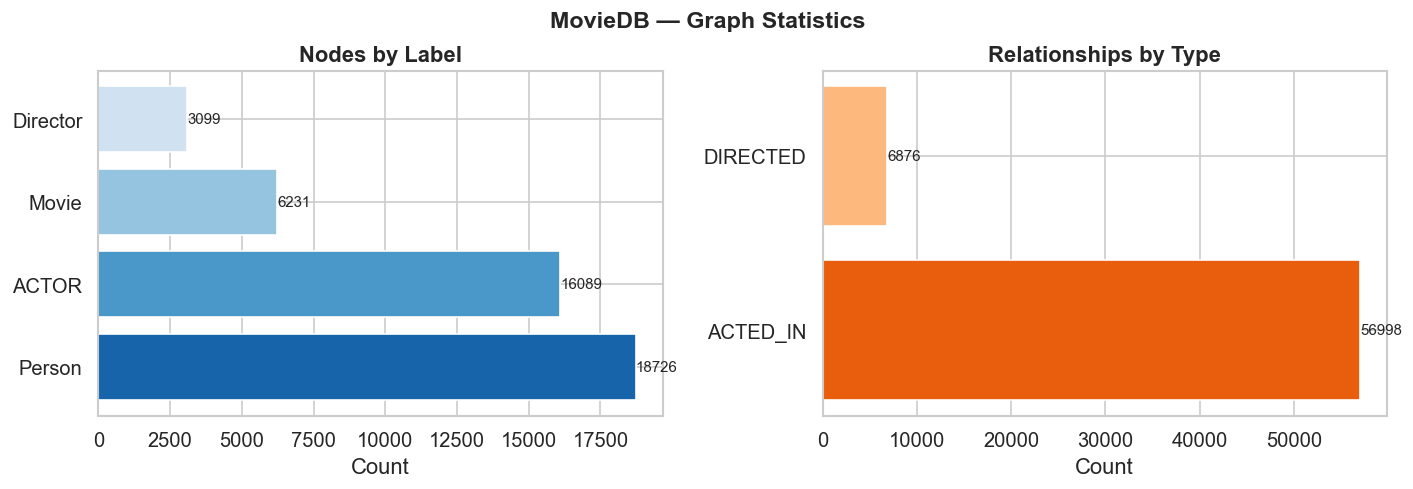

In [7]:
# ── Bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nodes
axes[0].barh(node_counts['label'], node_counts['count'],
             color=sns.color_palette('Blues_r', len(node_counts)))
axes[0].set_xlabel('Count')
axes[0].set_title('Nodes by Label', fontweight='bold')
for i, v in enumerate(node_counts['count']):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# Relationships
axes[1].barh(rel_counts['type'], rel_counts['count'],
             color=sns.color_palette('Oranges_r', len(rel_counts)))
axes[1].set_xlabel('Count')
axes[1].set_title('Relationships by Type', fontweight='bold')
for i, v in enumerate(rel_counts['count']):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('MovieDB — Graph Statistics', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 1.3 Degree Distribution

In [8]:
# ── Degree of Person nodes (number of relationships per person) ───────────────
person_degree = run_query("""
MATCH (p:Person)-[r]-()
RETURN p.name AS person, count(r) AS degree
ORDER BY degree DESC
""")

print(f"Person degree stats:\n{person_degree['degree'].describe().round(2)}\n")
print("Top 10 most-connected people:")
person_degree.head(10).to_string(index=False)

Person degree stats:
count    18672.00
mean         3.42
std          4.73
min          1.00
25%          1.00
50%          2.00
75%          4.00
max         75.00
Name: degree, dtype: float64

Top 10 most-connected people:


'           person  degree\nSamuel L. Jackson      75\n   Robert De Niro      63\n     Bruce Willis      63\n   Clint Eastwood      62\n      Woody Allen      57\n   Morgan Freeman      50\n     Nicolas Cage      48\n      Jackie Chan      47\n       Matt Damon      45\n   Robin Williams      45'

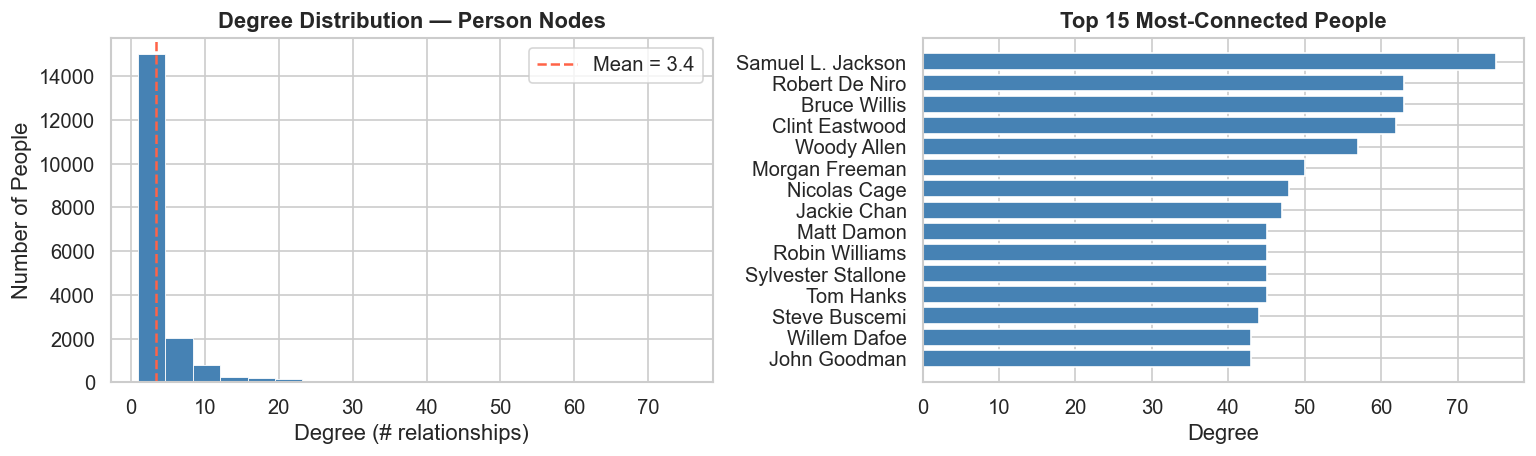

In [9]:
# ── Degree distribution histogram ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(person_degree['degree'], bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Degree (# relationships)')
axes[0].set_ylabel('Number of People')
axes[0].set_title('Degree Distribution — Person Nodes', fontweight='bold')
axes[0].axvline(person_degree['degree'].mean(), color='tomato', linestyle='--', label=f"Mean = {person_degree['degree'].mean():.1f}")
axes[0].legend()

# Top 15 people by degree
top15 = person_degree.head(15)
axes[1].barh(top15['person'][::-1], top15['degree'][::-1], color='steelblue')
axes[1].set_xlabel('Degree')
axes[1].set_title('Top 15 Most-Connected People', fontweight='bold')

plt.tight_layout()
plt.show()

## 1.4 Release Year Distribution

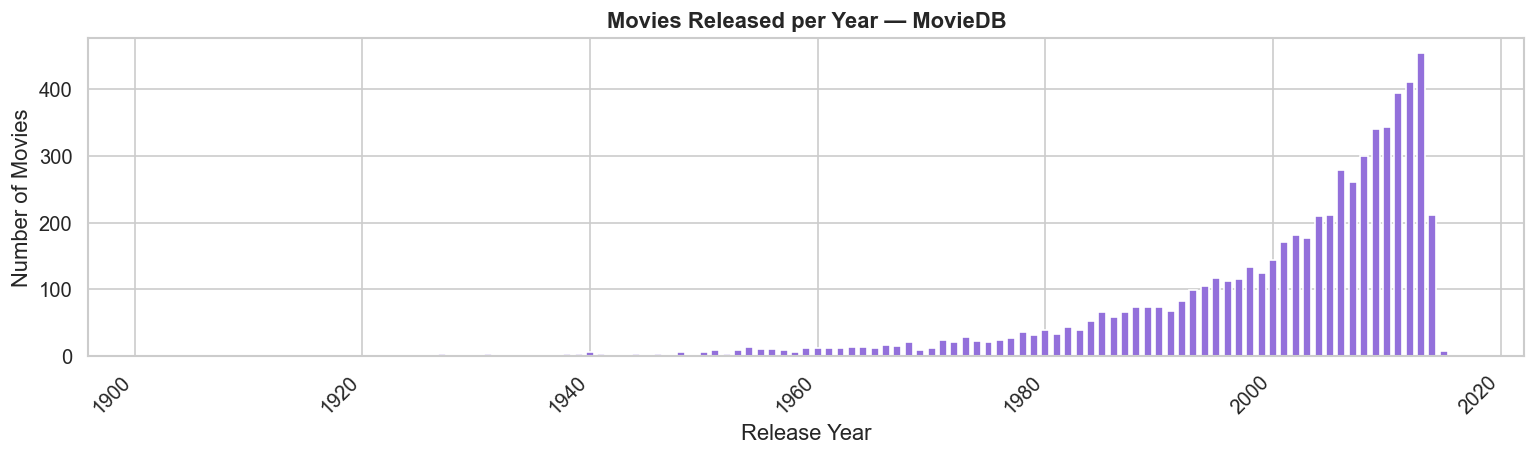

In [10]:
# ── Movies per release year ───────────────────────────────────────────────────
year_df = run_query("""
MATCH (m:Movie)
WHERE m.releaseYear IS NOT NULL
RETURN m.releaseYear AS year, count(*) AS movies
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(year_df['year'], year_df['movies'], color='mediumpurple', width=0.7)
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Movies')
ax.set_title('Movies Released per Year — MovieDB', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 1.5 Role Distribution

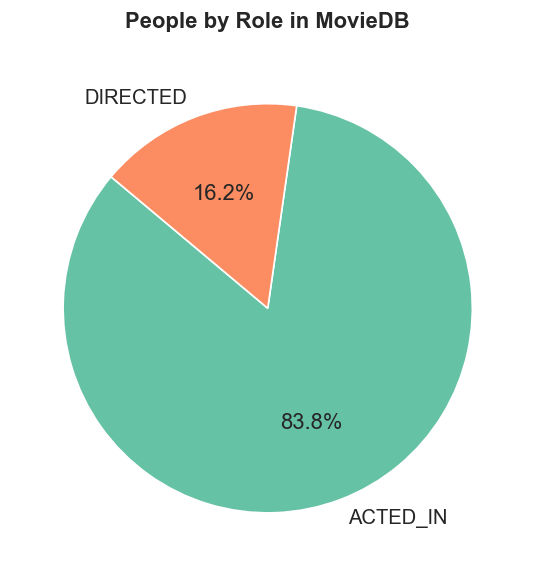

    role  people
ACTED_IN   16089
DIRECTED    3099


In [11]:
# ── How many people are actors vs directors? ─────────────────────
role_df = run_query("""
MATCH (p:Person)-[r]->(m:Movie)
RETURN type(r) AS role, count(DISTINCT p) AS people
ORDER BY people DESC
""")

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    role_df['people'],
    labels=role_df['role'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(role_df))
)
ax.set_title('People by Role in MovieDB', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(role_df.to_string(index=False))

---

# 🎯 Session 2 — Cypher Queries & Meaningful Visualisations

> *"The right query reveals the story hidden in the graph."*

In this session we will:
1. Identify the most prolific directors
2. Find co-actors (people who acted together)
3. Detect the shortest path between two people
4. Build a sub-graph of Tom Hanks' movies and render it with NetworkX
5. Perform a collaborative-filtering style recommendation

## 2.1 Most Prolific Directors

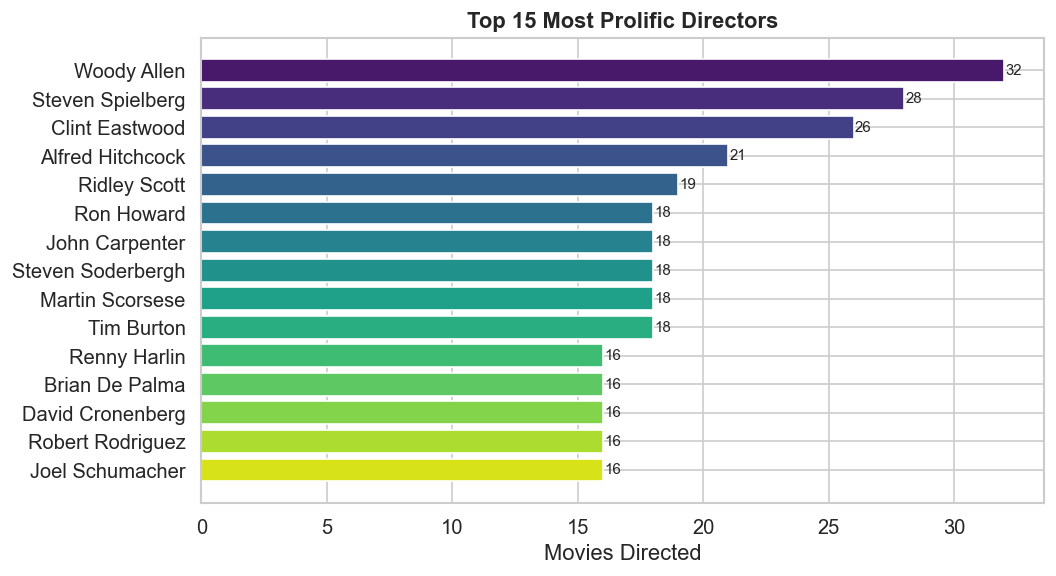

In [12]:
directors_df = run_query("""
MATCH (d:Person)-[:DIRECTED]->(m:Movie)
RETURN d.name AS director, count(m) AS movies_directed
ORDER BY movies_directed DESC
LIMIT 15
""")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    directors_df['director'][::-1],
    directors_df['movies_directed'][::-1],
    color=sns.color_palette('viridis', len(directors_df))[::-1]
)
ax.set_xlabel('Movies Directed')
ax.set_title('Top 15 Most Prolific Directors', fontweight='bold')
for bar, v in zip(bars, directors_df['movies_directed'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2.2 Top Co-Acting Pairs

In [13]:
# ── Pairs of actors who appeared together in the most movies ──────────────────
coactors_df = run_query("""
MATCH (a1:Person)-[:ACTED_IN]->(m:Movie)<-[:ACTED_IN]-(a2:Person)
WHERE elementId(a1) < elementId(a2)          
RETURN a1.name AS actor_1,
       a2.name AS actor_2,
       count(DISTINCT m) AS shared_movies,
       collect(m.title)[..3]   AS sample_titles   
ORDER BY shared_movies DESC
LIMIT 15
""")

print("Top co-acting pairs:")
print(coactors_df[['actor_1','actor_2','shared_movies']].to_string(index=False))

Top co-acting pairs:
       actor_1          actor_2  shared_movies
  Adam Sandler     Allen Covert             13
  Lois Maxwell Desmond Llewelyn             12
  Frank Welker     Jim Cummings             11
   Bernard Lee     Lois Maxwell             11
  Terence Hill      Bud Spencer             10
   Owen Wilson      Ben Stiller              9
  Jeff Bennett     Jim Cummings              9
   Rob Paulsen     Jeff Bennett              9
   Bernard Lee Desmond Llewelyn              9
 Steve Buscemi     Adam Sandler              8
Bruce Campbell        Ted Raimi              8
   Peter Dante     Allen Covert              8
 Rob Schneider     Adam Sandler              8
  Maggie Smith    Julie Walters              8
   Kevin Smith      Jason Mewes              8


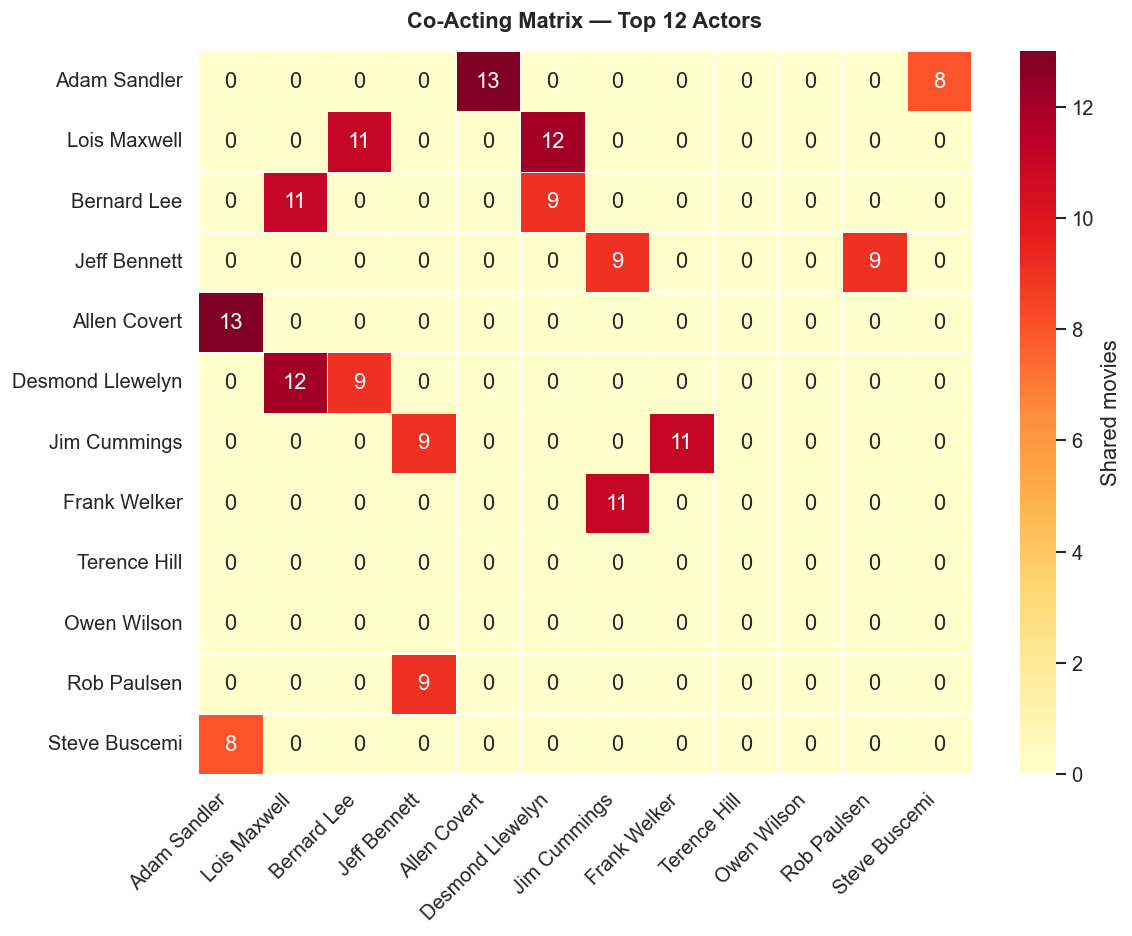

In [14]:
# ── Heatmap — top actors vs shared movies ─────────────────────────────────────
# Build a square matrix for the top N actors
TOP_N = 12
top_actors = list(
    pd.concat([coactors_df['actor_1'], coactors_df['actor_2']])
    .value_counts()
    .head(TOP_N)
    .index
)

matrix = pd.DataFrame(0, index=top_actors, columns=top_actors)
for _, row in coactors_df.iterrows():
    a1, a2, count = row['actor_1'], row['actor_2'], row['shared_movies']
    if a1 in top_actors and a2 in top_actors:
        matrix.loc[a1, a2] = count
        matrix.loc[a2, a1] = count

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.4,
            ax=ax, cbar_kws={'label': 'Shared movies'})
ax.set_title(f'Co-Acting Matrix — Top {TOP_N} Actors', fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 2.3 Shortest Path Between Two People

In [15]:
# ── Six degrees of separation: shortest path between two people ───────────────
PERSON_A = 'Kevin Bacon'
PERSON_B = 'Meg Ryan'

path_df = run_query(f"""
MATCH path = shortestPath(
    (a:Person {{name: $a}})-[*]-(b:Person {{name: $b}})
)
RETURN [node IN nodes(path) | coalesce(node.name, node.title)] AS path_nodes,
       length(path) AS hops
""", {'a': PERSON_A, 'b': PERSON_B})

if path_df.empty:
    print(f'No path found between {PERSON_A} and {PERSON_B}.')
else:
    hops = path_df['hops'].iloc[0]
    path_nodes = path_df['path_nodes'].iloc[0]
    print(f"Shortest path ({hops} hops): {PERSON_A} → {PERSON_B}\n")
    print(" → ".join(path_nodes))

Shortest path (4 hops): Kevin Bacon → Meg Ryan

Kevin Bacon → New York, I Love You → Cloris Leachman → The Women → Meg Ryan


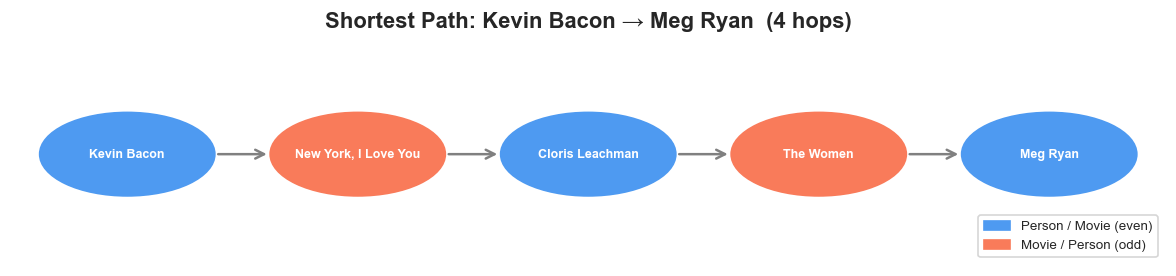

In [16]:
# ── Visualise the path as a simple horizontal chain ───────────────────────────
if not path_df.empty:
    nodes = path_df['path_nodes'].iloc[0]
    n = len(nodes)
    fig, ax = plt.subplots(figsize=(max(10, n * 2), 2.5))
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-1, 1)
    ax.axis('off')

    colors = ['#4e9af1' if i % 2 == 0 else '#f97b5a' for i in range(n)]
    for i, (name, color) in enumerate(zip(nodes, colors)):
        circle = plt.Circle((i, 0), 0.38, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(i, 0, name, ha='center', va='center', fontsize=7.5,
                fontweight='bold', color='white', zorder=4,
                wrap=True)
        if i < n - 1:
            ax.annotate('', xy=(i + 0.62, 0), xytext=(i + 0.38, 0),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

    blue_p  = mpatches.Patch(color='#4e9af1', label='Person / Movie (even)')
    orange_p = mpatches.Patch(color='#f97b5a', label='Movie / Person (odd)')
    ax.legend(handles=[blue_p, orange_p], loc='lower right', fontsize=8)
    ax.set_title(f'Shortest Path: {PERSON_A} → {PERSON_B}  ({hops} hops)',
                 fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

## 2.4 Collaborative-Filtering Recommendation

The idea: *"Find movies that people who acted with Tom Hanks appeared in, but Tom Hanks himself has never been in."*  
This is a classic **two-hop recommendation** pattern on a graph.

In [17]:
ANCHOR='Tom Hanks'  # ← change this to your favorite actor/actress
reco_df = run_query(f"""
MATCH (anchor:Person {{name: $anchor}})-[:ACTED_IN]->(m:Movie)<-[:ACTED_IN]-(coactor:Person)
MATCH (coactor)-[:ACTED_IN]->(rec:Movie)
WHERE NOT (anchor)-[:ACTED_IN]->(rec)
  AND rec <> m
RETURN rec.title       AS recommended_movie,
       rec.released    AS year,
       count(DISTINCT coactor) AS supporting_coactors,
       collect(DISTINCT coactor.name)[..4] AS because_of
ORDER BY supporting_coactors DESC
LIMIT 15
""", {'anchor': ANCHOR})

print(f"Top movie recommendations for fans of {ANCHOR}:\n")
print(reco_df[['recommended_movie', 'year', 'supporting_coactors']].to_string(index=False))

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `released` does not exist in database `movies`. Verify that the spelling is correct.', position=<SummaryInputPosition line=7, column=12, offset=242>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 242, 'line': 7, 'column': 12}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (anchor:Person {name: $anchor})-[:ACTED_IN]->(m:Movie)<-[:ACTED_IN]-(coactor:Person)\nMATCH (coactor)-[:ACTED_IN]->(rec:Movie)\nWHERE NOT (anchor)-[:ACTED_IN]->(rec)\n  AND rec <> m\nRETURN rec.title       AS recommended_movie,\n       rec.released    AS year,\n       count(DISTINCT coactor) AS support

Top movie recommendations for fans of Tom Hanks:

       recommended_movie year  supporting_coactors
          Monsters, Inc. None                    9
                Godzilla None                    8
The Silence of the Lambs None                    7
                    1941 None                    7
             Patch Adams None                    6
               Celebrity None                    6
              Awakenings None                    6
         The Incredibles None                    6
            Now and Then None                    6
        A Beautiful Mind None                    5
                  Cars 2 None                    5
            Out of Sight None                    5
             Big Trouble None                    5
                 Titanic None                    5
            Finding Nemo None                    5


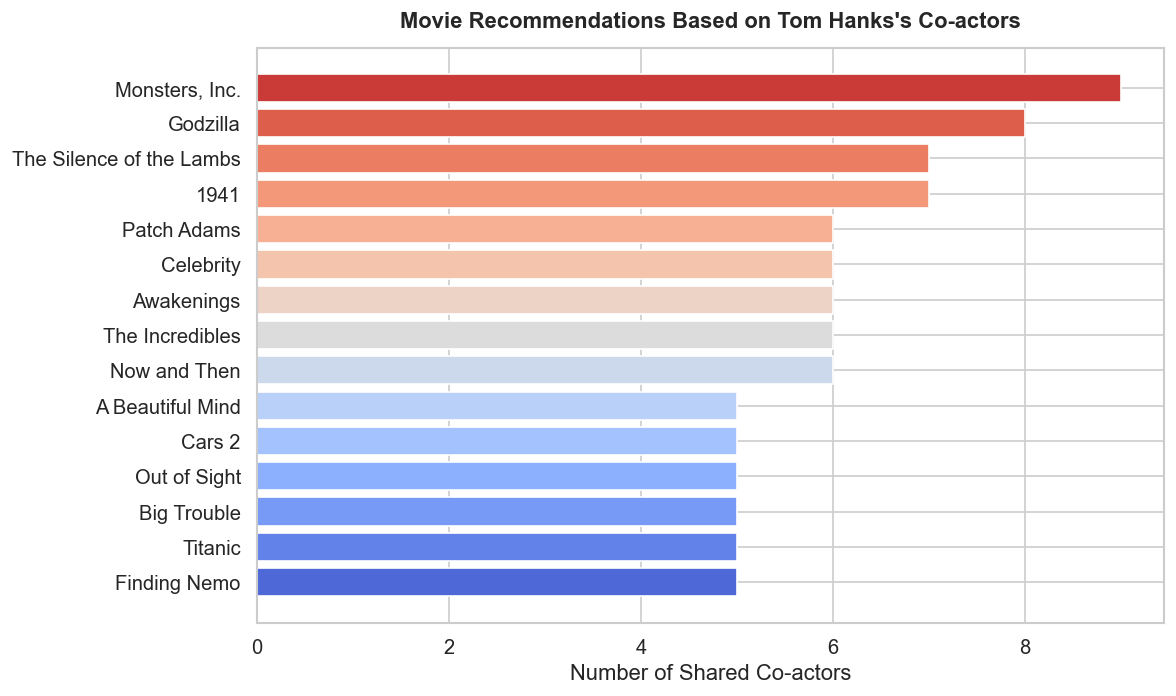

In [18]:
# ── Horizontal bar chart of recommendations ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('coolwarm', len(reco_df))

ax.barh(
    reco_df['recommended_movie'][::-1],
    reco_df['supporting_coactors'][::-1],
    color=palette
)
ax.set_xlabel('Number of Shared Co-actors')
ax.set_title(f'Movie Recommendations Based on {ANCHOR}\'s Co-actors',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 2.5 Bonus — Movies with the Largest Casts

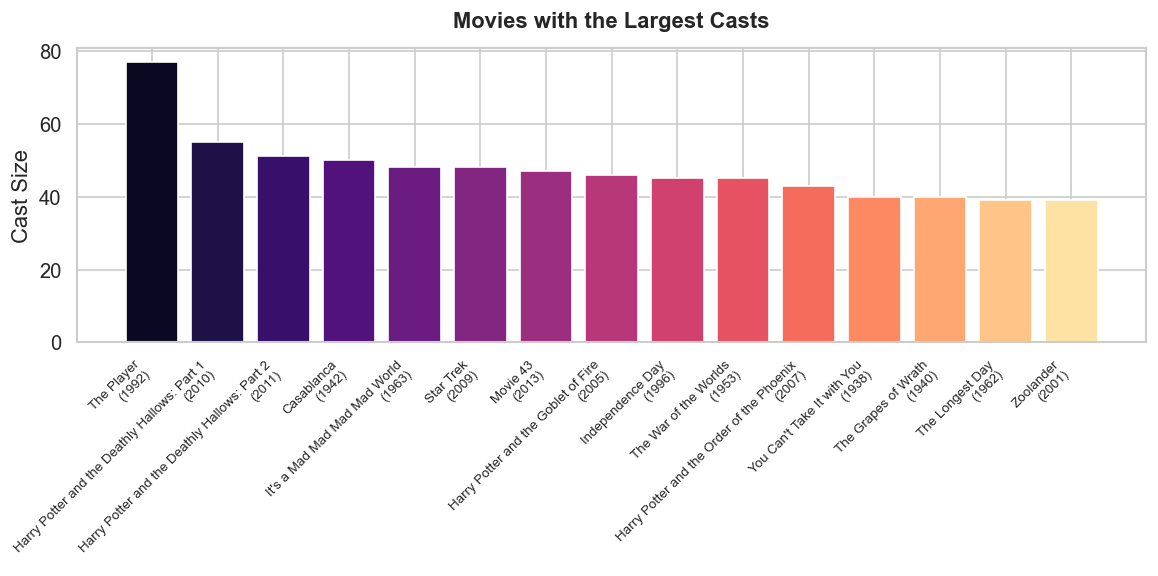

In [19]:
cast_df = run_query("""
MATCH (p:Person)-[:ACTED_IN]->(m:Movie)
RETURN m.title AS movie, m.releaseYear AS year, count(p) AS cast_size
ORDER BY cast_size DESC
LIMIT 15
""")

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('magma', len(cast_df))
ax.bar(range(len(cast_df)), cast_df['cast_size'], color=colors)
ax.set_xticks(range(len(cast_df)))
ax.set_xticklabels(
    [f"{t}\n({y})" for t, y in zip(cast_df['movie'], cast_df['year'])],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Cast Size')
ax.set_title('Movies with the Largest Casts', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---

# 🎓 Session 3 — Exercises

This session contains **8 graded exercises** covering the full range of skills practised in Sessions 1 and 2.  
Each exercise states the **learning objective**, provides a **scaffold** (imports and helper calls are already set up), and ends with an **auto-grader cell** that checks your answer.

| # | Topic | Difficulty |
|---|-------|------------|
| 3.1 | Cypher basics — filtering & aggregation | ⭐ |
| 3.2 | Multi-hop traversal | ⭐⭐ |
| 3.3 | Degree & centrality analysis | ⭐⭐ |
| 3.4 | Pattern matching & NOT clauses | ⭐⭐ |

---

> 💡 **Instructions**  
> - Replace every `# YOUR CODE HERE` block with your solution.  
> - Run the **grader cell** directly below each exercise to check your result.  
> - Graders print ✅ on success and ❌ with a hint on failure — they never reveal the full answer.

---
## Exercise 3.1 — Filtering & Aggregation ⭐

**Objective:** Practise basic `MATCH … WHERE … RETURN` patterns and aggregation in Cypher.

**Task:**  
Write a Cypher query that returns every **movie released in the 1990s** (year ≥ 1990 and year ≤ 1999), along with its title and release year, sorted by year ascending and then alphabetically by title.

*Expected columns:* `title`, `year`

In [25]:
# ── Exercise 3.1 ─────────────────────────────────────────────────────────────
# Write your Cypher query as a string assigned to `cypher_3_1`

cypher_3_1 = """
MATCH (m:Movie) 
WHERE m.releaseYear >= 1990 AND m.releaseYear <= 1999
RETURN m.title, m.releaseYear
ORDER BY m.title DESC
"""

df_3_1 = run_query(cypher_3_1)
df_3_1

,m.title,m.releaseYear
0,eXistenZ,1999
1,Young Guns II,1990
2,You've Got Mail,1998
3,Wyatt Earp,1994
4,Wolf,1994
...,...,...
1027,23,1999
1028,187,1997
1029,1492: Conquest of Paradise,1992
1030,101 Dalmatians,1996


In [24]:
# ── Grader 3.1 ────────────────────────────────────────────────────────────────
def grade_3_1(df):
    errors = []
    if df.empty:
        errors.append('DataFrame is empty — query returned no rows.')
    else:
        required_cols = {'title', 'year'}
        if not required_cols.issubset(df.columns):
            errors.append(f'Missing columns. Expected {required_cols}, got {set(df.columns)}.')
        else:
            years = df['year'].tolist()
            if any(y < 1990 or y > 1999 for y in years):
                errors.append('Some rows fall outside the 1990-1999 range — check your WHERE clause.')
            if years != sorted(years):
                errors.append('Rows are not sorted by year ascending.')
    if errors:
        for e in errors:
            print(f'  ❌ {e}')
    else:
        print(f'  ✅ Correct! {len(df)} movies from the 1990s returned in the right order.')

grade_3_1(df_3_1)

  ❌ Missing columns. Expected {'title', 'year'}, got {'m.title', 'm.releaseYear'}.


---
## Exercise 3.2 — Multi-hop Traversal ⭐⭐

**Objective:** Understand variable-length path patterns in Cypher.

**Task:**  
Find all **Person** nodes that are exactly **2 hops** away from `'Tom Hanks'` through `ACTED_IN` relationships only (i.e. co-actors of Tom Hanks' co-actors, excluding Tom Hanks himself and anyone who acted directly with him).

Return `name` and the number of distinct paths (`paths`) that connect them to Tom Hanks at distance 2, ordered by `paths` descending.  

*Expected columns:* `name`, `paths`

In [ ]:
# ── Exercise 3.2 ─────────────────────────────────────────────────────────────
cypher_3_2 = """
MATCH path=(Tom:Person)-[:ACTED_IN]->(m1:Movie)<-[:ACTED_IN]-(p:Person)-[:ACTED_IN]->(m2:Movie)<-[:ACTED_IN]-(o:Person)
WHERE Tom.name = 'Tom Hanks' AND NOT (Tom)-[:ACTED_IN]->()<-[:ACTED_IN]-(o) AND NOT Tom=o
RETURN o.name, count(DISTINCT path) as paths
ORDER BY paths DESC
"""

df_3_2 = run_query(cypher_3_2)
df_3_2.head(10)

,o.name,paths
0,Samuel L. Jackson,98
1,Steve Buscemi,90
2,Robin Williams,79
3,Sigourney Weaver,66
4,John Cusack,66
5,Patrick Warburton,65
6,Ben Affleck,63
7,Willem Dafoe,62
8,Billy Crystal,59
9,Nicolas Cage,58


In [27]:
# ── Grader 3.2 ────────────────────────────────────────────────────────────────
def grade_3_2(df):
    errors = []
    if df.empty:
        errors.append('DataFrame is empty — query returned no rows.')
    else:
        if 'Tom Hanks' in df['name'].values:
            errors.append('Tom Hanks should be excluded from the results.')
        if not {'name', 'paths'}.issubset(df.columns):
            errors.append('Missing columns — expected `name` and `paths`.')
        else:
            paths_col = df['paths'].tolist()
            if paths_col != sorted(paths_col, reverse=True):
                errors.append('Results should be ordered by `paths` descending.')
            if df['paths'].min() < 1:
                errors.append('`paths` count should be ≥ 1 for every row.')
    if errors:
        for e in errors:
            print(f'  ❌ {e}')
    else:
        print(f'  ✅ Correct! {len(df)} distinct people found at distance-2 from Tom Hanks.')

In [28]:
grade_3_2(df_3_2)

KeyError: 'name'

---
## Exercise 3.3 — Degree & Centrality Analysis ⭐⭐

**Objective:** Compute node degree from raw graph data and interpret the distribution.

**Task — two parts:**

**Part A (Cypher):** Retrieve the **in-degree** of each `Movie` node — i.e. the number of `Person` nodes that have any relationship pointing *to* that movie.  
Return `title`, `in_degree`, sorted descending. Assign to `df_3_3`.

**Part B (Python):** Using `df_3_3`, compute and print:
- The mean and median in-degree across all movies
- The name of the movie(s) with the highest in-degree
- A histogram of the in-degree distribution (use Matplotlib)

In [29]:
# ── Exercise 3.3 — Part A ─────────────────────────────────────────────────────
cypher_3_3 = """
MATCH path=()-[]->(m:Movie)
RETURN m.title, count(DISTINCT path) 
ORDER BY count(DISTINCT path) DESC
"""

df_3_3 = run_query(cypher_3_3)
df_3_3.head()

,m.title,count(DISTINCT path)
0,The Player,78
1,Movie 43,58
2,Harry Potter and the Deathly Hallows: Part 1,56
3,Casino Royale,54
4,Harry Potter and the Deathly Hallows: Part 2,52


<Axes: ylabel='Frequency'>

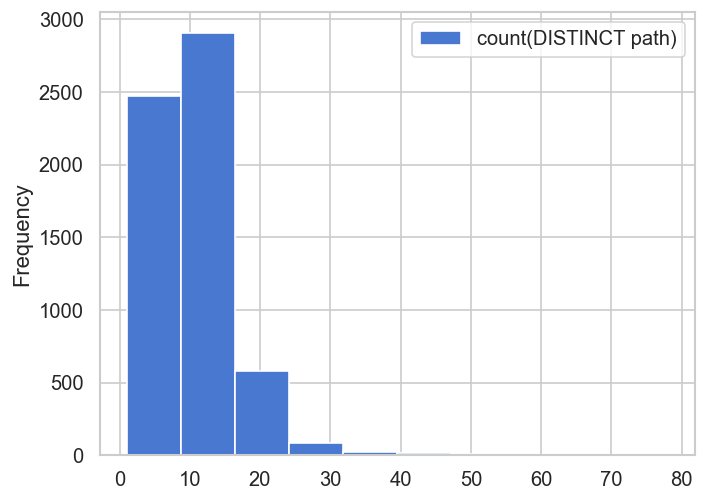

In [ ]:
# ── Exercise 3.3 — Part B ─────────────────────────────────────────────────────
# Compute mean, median, top movie(s), and plot the histogram
df_3_3['count(DISTINCT path)'].mean()
df_3_3['count(DISTINCT path)'].median()
#Top 5 since it's ordered
df_3_3.head(5)
df_3_3.plot.hist()
#Through the instogram we are able to see that the majority of our film has 10-20 connections.
#Followed by film that have from 0 to 10 connection. 
# Increasing the number of connection with actors and directors and staffs the number of films decrease.

In [32]:
# ── Grader 3.3 ────────────────────────────────────────────────────────────────
def grade_3_3(df):
    errors = []
    if df.empty:
        errors.append('DataFrame is empty.')
    else:
        if not {'title', 'in_degree'}.issubset(df.columns):
            errors.append('Missing columns — expected `title` and `in_degree`.')
        else:
            degs = df['in_degree'].tolist()
            if degs != sorted(degs, reverse=True):
                errors.append('Results should be sorted by `in_degree` descending.')
            if df['in_degree'].min() < 1:
                errors.append('Every movie should have at least 1 incoming relationship.')
            print(f'  ℹ️  Mean in-degree  : {df["in_degree"].mean():.2f}')
            print(f'  ℹ️  Median in-degree: {df["in_degree"].median():.1f}')
            print(f'  ℹ️  Top movie       : {df.iloc[0]["title"]} ({df.iloc[0]["in_degree"]} connections)')
    if errors:
        for e in errors:
            print(f'  ❌ {e}')
    else:
        print(f'  ✅ Part A correct! {len(df)} movies with valid in-degree values.')

grade_3_3(df_3_3)

  ❌ Missing columns — expected `title` and `in_degree`.


---
## Exercise 3.4 — Pattern Matching with NOT ⭐⭐

**Objective:** Use negative pattern matching (`NOT EXISTS` / `NOT (…)`) to filter graph results.

**Task:**  
Find all `Person` nodes who have **directed** at least one movie but have **never acted** in any movie.  
Return `name` and `directed` (count of movies they directed), sorted by `directed` descending.

*Expected columns:* `name`, `directed`

In [33]:
# ── Exercise 3.4 ─────────────────────────────────────────────────────────────
cypher_3_4 = """
MATCH path=(actor:Person)-[:DIRECTED]->(m:Movie)
WHERE NOT (actor)-[:ACTED_IN]->()
RETURN actor.name, count(DISTINCT path)
ORDER BY count(DISTINCT path) DESC
"""

df_3_4 = run_query(cypher_3_4)
df_3_4

,actor.name,count(DISTINCT path)
0,Ridley Scott,19
1,Tim Burton,18
2,Brian De Palma,16
3,Joel Coen,16
4,Ethan Coen,16
...,...,...
2625,Jeff Renfroe,1
2626,Eric England,1
2627,Andy Cadiff,1
2628,Futoshi Higashide,1


In [34]:
# ── Grader 3.4 ────────────────────────────────────────────────────────────────
def grade_3_4(df):
    errors = []
    if df.empty:
        errors.append('DataFrame is empty — expected at least one director-only person.')
    else:
        if not {'name', 'directed'}.issubset(df.columns):
            errors.append('Missing columns — expected `name` and `directed`.')
        else:
            # Cross-check: none of these people should appear as actors
            actor_check = run_query("""
                MATCH (p:Person)-[:ACTED_IN]->()
                RETURN p.name AS name
            """)
            actors = set(actor_check['name'].tolist())
            overlap = set(df['name'].tolist()) & actors
            if overlap:
                errors.append(f'{len(overlap)} person(s) in your result also acted in movies: {list(overlap)[:3]}')
            degs = df['directed'].tolist()
            if degs != sorted(degs, reverse=True):
                errors.append('Results must be sorted by `directed` descending.')
    if errors:
        for e in errors:
            print(f'  ❌ {e}')
    else:
        print(f'  ✅ Correct! {len(df)} director-only people found.')

grade_3_4(df_3_4)

  ❌ Missing columns — expected `name` and `directed`.


---

## 🔒 Close the Driver

In [35]:
driver.close()
print('Driver closed. ✅')

Driver closed. ✅


---

## 📚 Going Further

- Install **APOC** for richer schema introspection and path functions
- Try **Graph Data Science (GDS)** library for PageRank, community detection, and node embeddings
- Use **`neovis.js`** or **`pyvis`** for interactive in-browser graph visualisations
- Explore **GraphQL / Grandstack** to build an API on top of your graph

Happy querying! 🚀